## Planteamiento del problema

Conocer el comportamiento de los clientes es fundamental para cualquier negocio, ya que permite tomar decisiones informadas sobre la estrategia de marketing, la gestión de inventarios y la atención al cliente. En este contexto, es importante analizar el comportamiento de los clientes en función de sus características demográficas y sus hábitos de compra. Sin embargo, la segmentación de clientes puede ser un proceso complejo que requiere el uso de técnicas avanzadas de análisis de datos.

Utiliza un algoritmo de Uso de Geometría y Topología para la Ciencia de Datos para analizar el comportamiento de los clientes.

**Preguntas de Investigación**

¿Existen patrones no lineales o estructuras complejas en el comportamiento de compra según el género, tipo de tarjeta, tipo de gasto y ciudad de los clientes?

¿Cómo se segmentan los clientes según su comportamiento de compra (Amount) en función de sus características demográficas?

## Carga - Construcción

En esta parte se cargan las librerias a usar, se carga la base de datos, se elimina la columna 'index' con la que viene el dataset y se visualiza para ver que todo esté en orden.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ripser import ripser
from persim import plot_diagrams
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import gudhi

import kmapper as km
from sklearn.cluster import KMeans

In [ ]:
# Lee el archivo
file_name = "credit_card_data.csv"
df_inicial = pd.read_csv(file_name)

# Drop the 'index' column
df = df_inicial.drop(columns=['index'])

# Display the first few rows of the dataframe to inspect
df.head()

,City,Date,Card Type,Exp Type,Gender,Amount
0,"Delhi, India",29-Oct-14,Gold,Bills,F,82475
1,"Greater Mumbai, India",22-Aug-14,Platinum,Bills,F,32555
2,"Bengaluru, India",27-Aug-14,Silver,Bills,F,101738
3,"Greater Mumbai, India",12-Apr-14,Signature,Bills,F,123424
4,"Bengaluru, India",5-May-15,Gold,Bills,F,171574


## Limpieza - Calidad - Análisis Estadístico

Se analizan las variables de la base de datos para saber que tipos de variables tenemos y que valores pueden tener. Luego se determina que se tiene que hacer (Encoding y Scaling) a que variables y finalmente se vuelven a visualizar los datos para asegurarnos de que todo está en orden.

### Analysis

In [ ]:
# Display the data types of all columns
df.dtypes


,0
City,object
Date,object
Card Type,object
Exp Type,object
Gender,object
Amount,int64


In [ ]:
# Get the unique strings in the column
unique_strings = df['City'].value_counts()
print(unique_strings)


City
Bengaluru, India         3552
Greater Mumbai, India    3493
Ahmedabad, India         3491
Delhi, India             3482
Hyderabad, India          784
                         ... 
Varanasi, India             1
Changanassery, India        1
Bagaha, India               1
Vellore, India              1
Fazilka, India              1
Name: count, Length: 986, dtype: int64


In [ ]:
# Get the 10 most common values in a specific column
top_10_values = df['City'].value_counts().head(20)
print(top_10_values)


City
Bengaluru, India           3552
Greater Mumbai, India      3493
Ahmedabad, India           3491
Delhi, India               3482
Hyderabad, India            784
Chennai, India              774
Kolkata, India              773
Kanpur, India               764
Lucknow, India              759
Jaipur, India               752
Surat, India                749
Pune, India                 747
Kalyan-Dombivali, India      19
Ramnagar, India              19
Vijayapura, India            15
Udaipur, India               15
Puliyankudi, India           14
Bathinda, India              14
Pratapgarh, India            14
Jind, India                  13
Name: count, dtype: int64


In [ ]:
# Get the unique strings in the column
unique_strings = df['Card Type'].value_counts()
print(unique_strings)


Card Type
Silver       6840
Signature    6447
Platinum     6398
Gold         6367
Name: count, dtype: int64


In [ ]:
# Get the unique strings in the column
unique_strings = df['Exp Type'].value_counts()
print(unique_strings)


Exp Type
Food             5463
Fuel             5257
Bills            5078
Entertainment    4762
Grocery          4754
Travel            738
Name: count, dtype: int64


In [ ]:
# Get the unique strings in the column
unique_strings = df['Gender'].value_counts()
print(unique_strings)


Gender
F    13680
M    12372
Name: count, dtype: int64


In [ ]:
# Contar la frecuencia de cada ciudad
city_counts = df['City'].value_counts()

# Obtener las 5 ciudades principales
top_4_cities = city_counts.head(4).index

# Filtrar el DataFrame para mantener solo las filas de las  5 principales ciudades
df_filtered = df[df['City'].isin(top_4_cities)]

# Ver el resultado
print(df_filtered['City'].value_counts())

City
Bengaluru, India         3552
Greater Mumbai, India    3493
Ahmedabad, India         3491
Delhi, India             3482
Name: count, dtype: int64


Arriba se corrieron 2 análisis de City para ver mas a detalle las entradas por ciudad. Ya que la mayoría de ciudades tienen muy pocas entradas, en el bloque anterior, se decidió dejar solamente los datos de las 4 ciudades mas grandes, así se reducen valores posibles (lo que hace mas sencillo el encoding de la columna), además que se reduce cantidad de datos, suficiente para aligerar la carga computacional en los siguientes análisis, pero se quedan suficientes también para que los análisis sean relevantes.

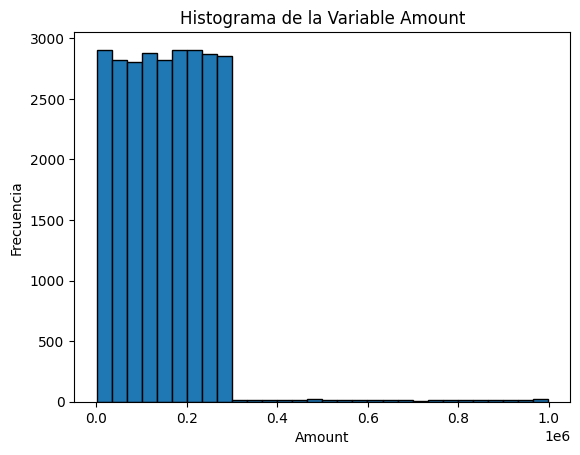

In [ ]:
# Supongamos que tienes un DataFrame llamado df
plt.hist(df['Amount'], bins=30, edgecolor='black')  # Ajusta los bins como necesites

plt.title('Histograma de la Variable Amount')
plt.xlabel('Amount')
plt.ylabel('Frecuencia')
plt.show()


A través del histograma se puede ver que la cantidad de las transacciones está, esta distribuida mayoritariamente entre un rango de 0 y 200,000 y hay una pequeña cantidad que se aleja mucho hasta llegar al millon.

### Target encoding

Se decidió usar target encoding, para hacer el encoding de las variables categoricas. El Target encoding funciona obteniendo el valor medio de la variable objetivo, de todas las entradas con el mismo valor en la variable a la que se le hace el encoding. Se decidió usar este método, ya que al guardar la relación con la variabel objetivo (a diferencia del label encoding) guarda mejor las características topológicas de los datos.

In [ ]:
# Calculate the mean 'Amount' for each city and encode the 'City' column
city_target_encoding = df.groupby('City')['Amount'].mean()

# Map the encoded values back to the original dataset
df['City_encoded'] = df['City'].map(city_target_encoding)

# Check the encoding
print(df[['City', 'City_encoded']].head())


                    City   City_encoded
0           Delhi, India  159945.207352
1  Greater Mumbai, India  165116.368737
2       Bengaluru, India  161128.023367
3  Greater Mumbai, India  165116.368737
4       Bengaluru, India  161128.023367


In [ ]:
# Perform target encoding (mean of 'Amount' for each 'Card Type')
card_type_target_encoding = df.groupby('Card Type')['Amount'].mean()

# Map the encoding back to the DataFrame
df['Card Type_encoded'] = df['Card Type'].map(card_type_target_encoding)

# Check the result
print(df[['Card Type', 'Card Type_encoded']].head())


   Card Type  Card Type_encoded
0       Gold      154631.621800
1   Platinum      157492.813223
2     Silver      156376.273830
3  Signature      157133.721886
4       Gold      154631.621800


In [ ]:
exp_type_target_encoding = df.groupby('Exp Type')['Amount'].mean()
df['Exp Type_encoded'] = df['Exp Type'].map(exp_type_target_encoding)

# Check the result
print(df[['Exp Type', 'Exp Type_encoded']].head())

  Exp Type  Exp Type_encoded
0    Bills      178627.89937
1    Bills      178627.89937
2    Bills      178627.89937
3    Bills      178627.89937
4    Bills      178627.89937


In [ ]:
# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'Gender' column
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])

# Check the result
print(df[['Gender', 'Gender_encoded']].head())


  Gender  Gender_encoded
0      F               0
1      F               0
2      F               0
3      F               0
4      F               0


In [ ]:
df = df.drop(columns=['Date','City','Card Type','Exp Type','Gender'])


In [ ]:
df.head()

,Amount,City_encoded,Card Type_encoded,Exp Type_encoded,Gender_encoded
0,82475,159945.207352,154631.621800,178627.89937,0
1,32555,165116.368737,157492.813223,178627.89937,0
2,101738,161128.023367,156376.273830,178627.89937,0
3,123424,165116.368737,157133.721886,178627.89937,0
4,171574,161128.023367,154631.621800,178627.89937,0


### Scaling

Se escalan todas las variables, para que esten en la misma magnitud y de esa manera, no se vean afectados por ejemplo la reducción de dimensionalidad o el grafo del mapper que si son sensibles a la magnitud

In [ ]:
df.head()

,Amount,City_encoded,Card Type_encoded,Exp Type_encoded,Gender_encoded
0,82475,159945.207352,154631.621800,178627.89937,0
1,32555,165116.368737,157492.813223,178627.89937,0
2,101738,161128.023367,156376.273830,178627.89937,0
3,123424,165116.368737,157133.721886,178627.89937,0
4,171574,161128.023367,154631.621800,178627.89937,0


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# List all numeric columns you want to scale, including target-encoded and continuous features
# This includes 'Amount' and the encoded columns
numeric_columns = ['Amount', 'City_encoded', 'Card Type_encoded', 'Exp Type_encoded', 'Gender_encoded']  # Update this list if needed

# Initialize the scaler
scaler = StandardScaler()

# Scale the selected numeric columns
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])


### Visualización de Datos preprocesados

Se verifica que el encoding y scaling se hallan hecho correctamente y revisamos la distribución de los valores de amount, que no han cambiado.

In [ ]:
# Now, let's check the scaled 'Amount' and other scaled target-encoded columns
print(df[numeric_columns].head())

     Amount  City_encoded  Card Type_encoded  Exp Type_encoded  Gender_encoded
0 -0.717404      0.192592          -1.631104          2.025175       -0.950992
1 -1.201776      0.474430           0.990874          2.025175       -0.950992
2 -0.530495      0.257057          -0.032315          2.025175       -0.950992
3 -0.320077      0.474430           0.661805          2.025175       -0.950992
4  0.147121      0.257057          -1.631104          2.025175       -0.950992


In [ ]:
# Obtener el valor más alto de cada columna
max_values = df.max()

print(max_values)


Amount               8.166651
City_encoded         7.645114
Card Type_encoded    0.990874
Exp Type_encoded     2.025175
Gender_encoded       1.051533
dtype: float64


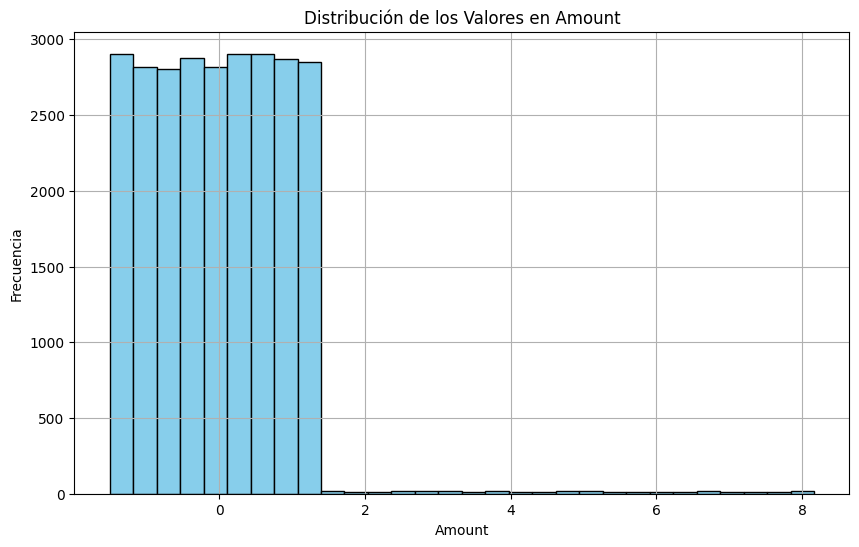

In [ ]:
import matplotlib.pyplot as plt

# Histograma para ver la distribución de 'Amount'
plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de los Valores en Amount')
plt.xlabel('Amount')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


## TDA

### Análisis de Persistencia - Persistence Bar Code y Persistence Diagram


 El análisis de persistencia nos permite explorar la topología subyacente de los datos, lo cual puede revelar patrones ocultos, relaciones complejas y grupos significativos entre las variables. Esto puede ser muy útil por ejemplo, con las variables categóricas (que en este caso, tenemos varias)

In [ ]:
#!pip install gudhi ripser persim

In [ ]:
# Assuming df is your preprocessed DataFrame (scaled and encoded columns)

# Step 1: Sample 500 random data points from the DataFrame
df_sample = df.sample(n=500, random_state=42)

# Step 2: Apply PCA for dimensionality reduction (to 3 components)
pca = PCA(n_components=3)

# Get the features (encoded and scaled columns)
features = ['City_encoded', 'Card Type_encoded', 'Exp Type_encoded', 'Gender_encoded']  # Use actual column names
X_sample = df_sample[features]

# Scale the data if not already scaled
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# Reduce to 3 components
X_reduced = pca.fit_transform(X_sample_scaled)

# Step 3: Compute persistent homology using Ripser
result = ripser(X_reduced, maxdim=2)
diagrams = result['dgms']

# Extracting the diagrams for H_0 (connected components) and H_1 (loops)
dmg0 = diagrams[0]  # H_0
dmg1 = diagrams[1]  # H_1

# Step 4: Convert persistence diagrams to DataFrames
# H_0 (connected components)
huecos0 = pd.DataFrame(dmg0, columns=['Birth', 'Death'])
huecos0['Life'] = huecos0['Death'] - huecos0['Birth']
huecos0 = huecos0.sort_values(by='Life', ascending=False)

# H_1 (loops)
huecos1 = pd.DataFrame(dmg1, columns=['Birth', 'Death'])
huecos1['Life'] = huecos1['Death'] - huecos1['Birth']
huecos1 = huecos1.sort_values(by='Life', ascending=False)

Se redujo la cantidad de datos utilizados para el persistence diagram y barcode a 500, ya que de otra forma se llena la RAM y no se logra hacer el análisis.

H_0 components (connected components):
     Birth         Death          Life
382    0.0           inf           inf
381    0.0  2.341202e+00  2.341202e+00
380    0.0  2.283079e+00  2.283079e+00
379    0.0  2.161080e+00  2.161080e+00
378    0.0  1.499877e+00  1.499877e+00
..     ...           ...           ...
4      0.0  2.107342e-08  2.107342e-08
3      0.0  2.107342e-08  2.107342e-08
2      0.0  2.107342e-08  2.107342e-08
1      0.0  2.107342e-08  2.107342e-08
0      0.0  2.107342e-08  2.107342e-08

[383 rows x 3 columns]

H_1 components (loops):
       Birth     Death      Life
6   1.730257  2.280953  0.550696
17  1.491862  1.905244  0.413382
5   1.732499  2.027693  0.295194
2   2.119380  2.322120  0.202740
28  1.071990  1.214038  0.142049
..       ...       ...       ...
82  0.143181  0.146018  0.002837
80  0.143181  0.146018  0.002837
24  1.320391  1.323210  0.002819
14  1.537883  1.539624  0.001741
13  1.538697  1.539266  0.000569

[116 rows x 3 columns]


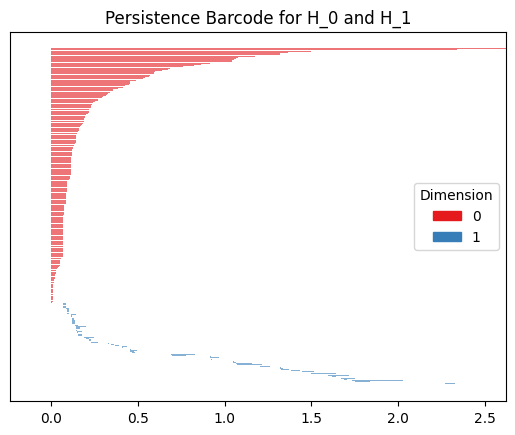

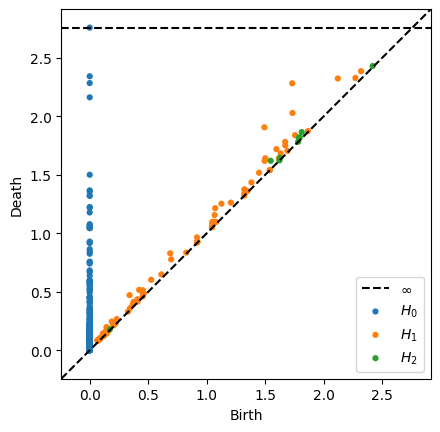

In [ ]:
# Display all the components
print("H_0 components (connected components):")
print(huecos0)

print("\nH_1 components (loops):")
print(huecos1)

# Step 5: Visualize the persistence diagrams for H_0 and H_1 using Gudhi
# Combine both H_0 and H_1 into the same barcode plot
# Step 6: Create a Rips complex using Gudhi (same data used for Ripser)
rips_complex = gudhi.RipsComplex(points=X_reduced, max_edge_length=3)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)

# Compute persistence with Gudhi, considering the min_persistence threshold
diag = simplex_tree.persistence(min_persistence=0)

# Step 7: Plot the persistence barcode for both H_0 and H_1
gudhi.plot_persistence_barcode(diag)

# Show the plot
plt.title("Persistence Barcode for H_0 and H_1")
plt.show()

# Step 8: Visualize the persistence diagrams using Ripser
plot_diagrams(diagrams, show=True)

**Interpretación de gráficos**

**Persistence Barcode:** Podemos ver como en $H_0$ la duración de los componentes topológicos se comporta como una gráfica con decaimiento exponencial, muy pocos componentes tienen una duración significativa. Por otro lado, en $H_1$, vemos longitudes muy pequeñas.

**Persistance Diagram:** Podemos ver como en $H_0$, solo hay 3 componentes (además del infinito) que tienen una duración mayor a 2. Por otro lado, en $H_1$, vemos que casi todos los componentes estan pegados a la diagonal, lo que significa que no son significativos, lo mismo para $H_2$.

In [ ]:
# Asumimos que 'diagrams' es el resultado de 'ripser', y 'dmg0' es el diagrama de H0
dmg0 = diagrams[0]

# Convertimos 'dmg0' en un DataFrame para facilitar el manejo
df_dmg0 = pd.DataFrame(dmg0, columns=['Birth', 'Death'])

# Calculamos la persistencia (Life) de cada componente
df_dmg0['Life'] = df_dmg0['Death'] - df_dmg0['Birth']

# Filtrar los componentes con Life > 2
high_persistence_components = df_dmg0[df_dmg0['Life'] > 1.5]

# Ver los resultados
print(high_persistence_components)


     Birth     Death      Life
379    0.0  2.161080  2.161080
380    0.0  2.283079  2.283079
381    0.0  2.341202  2.341202
382    0.0       inf       inf


Aquí podemos ver como en $H_0$ ni siquiera con una duración de 1.5 hay mas componentes significativos que los 3 que habíamos identificado en el diagrama.

**Interpretación:** Los datos no tienen estructuras topológicas complejas, lo que significa que para hacer clustering, por ejemplo, es suficiente con utilizar un método más tradicional como kmeans.

### Mapper

Aunque arriba dijimos que es suficiente con utilizar técnicas tradicionales para hacer clustering, vamos a utilizar kmappers, ya que el grafo obtenido de transformar de esta manera los datos, nos puede dar otros insights que ni el análisis de persistencia ni una técnica de clustering tradicional nos podrían dar.

In [ ]:
#!pip install kmapper

In [ ]:
# Paso 1: Crear el modelo Mapper
mapper = km.KeplerMapper(verbose=1)

# Paso 2: Proyección sobre todas las columnas codificadas
# Usamos todas las columnas relevantes como entrada para la proyección
x = df[['City_encoded','Card Type_encoded', 'Exp Type_encoded', 'Gender_encoded']].values

# Proyección sobre todas las características (Columnas codificadas)
projected_data = mapper.fit_transform(x)  # No es necesario especificar 'projection=[0]', ya que usamos todas las columnas

# Paso 3: Configuración de la cobertura (Cover)
covering = km.Cover(n_cubes=12, perc_overlap=0.2)

# Paso 4: Configurar el algoritmo de agrupamiento
clusterer = KMeans(n_clusters=3)

# Paso 5: Crear el grafo Mapper
G = mapper.map(
    projected_data,  # Datos proyectados en el espacio reducido
    x,               # Datos originales
    clusterer=clusterer,  # Algoritmo de clustering
    cover=covering   # Parámetros de cobertura
)

# Paso 6: Visualización del grafo
# Usamos 'Amount' para colorear los puntos
mapper.visualize(
    G,
    title='Mapper Visualization of Credit Card Spending Data',
    custom_tooltips=df['Gender_encoded'].to_numpy(),  # Mostrar 'Gender_encoded' en los tooltips
    color_values=df['Amount'].values,  # Colorear los puntos según 'Amount'
    color_function_name='Amount',  # Título para la coloración de los puntos
    node_color_function=np.array(['average', 'std', 'sum', 'max', 'min'])  # Opciones de color para nodos
)


KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: sum
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (26052, 4)

..Projecting data using: sum

..Scaling with: MinMaxScaler()

Mapping on data shaped (26052, 4) using lens shaped (26052, 1)

Creating 12 hypercubes.

Created 38 edges and 33 nodes in 0:00:00.192640.
Wrote visualization to: mapper_visualization_output.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Mapper Visualization of Credit Card Spending Data | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4

Para el Mapper, se utilizaron mas n_cubes y un menor overlap, para que se hicieran mas clusters y de esa manera ver si se forma un cluster (o varios) solo con (o mayoritariamente con) las entradas de valores >1 en Amount.

## Resultados

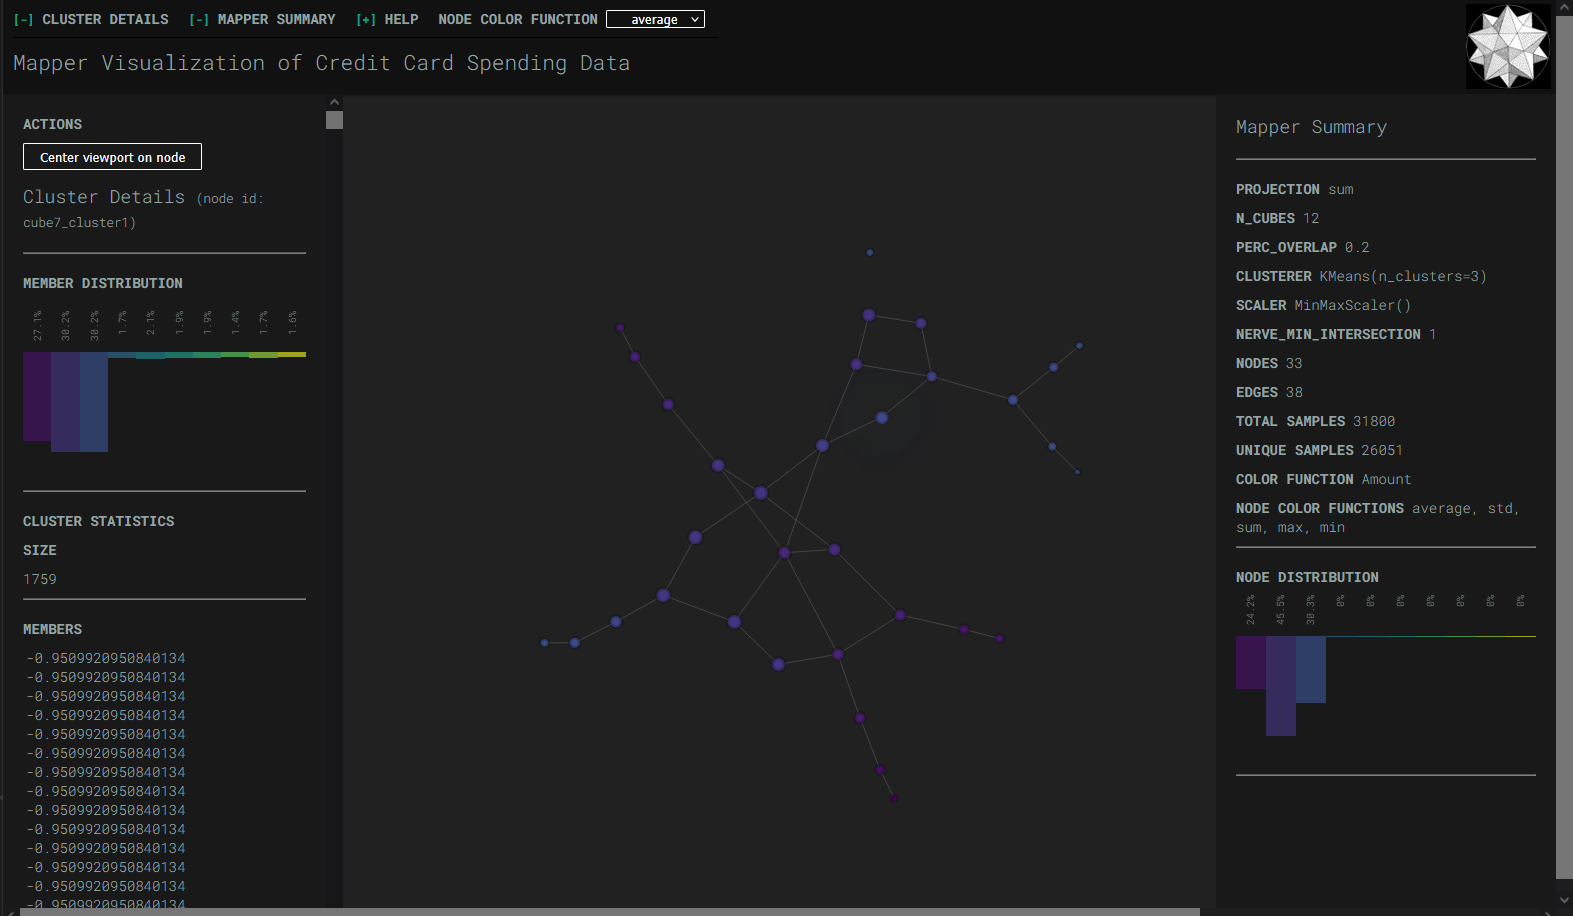

**Interpretación**

Del Kmapper obtuvimos el grafo de la imagen. El color es el que indica el gasto y como pudimos ver en los histogramas de arriba, la mayoría de los datos estan entre 0 y 1, con unos cuantos que llegan hasta 8.

Lo interesante es que estos datos que van hasta 8, no tienen características únicas que les permita formar un cluster, sino que son parte de 2 de los clusters centrales, bien conectados con otros clusters (lo que indica cierta similitud), esto nos indica que estos datos no son muy diferentes.

Además de esto, la estructura general del grafo es una cruz; los brazos horizontales tienen mas valores cercanos a 1, mientras que los brazos verticales tienen mas valores cercanos a 0. No quiere decir que esos nodos tengan exclusivamente de esos valores, en general están bastante mezclados, pero tienden mas hacia 1 u otro valor. Esto también indica que no hay mucha diferencia.

Esto podría ser, por los valores de amount que van hasta 8, si eliminaramos esas entradas, el análisis sería mas sensible a cambios dentro de 0 y 1, pero consideré relevante mantener esas entradas, ya que por su naturaleza pudieron haber tenido características diferentes.

**Conclusión**

Al final concuerda con lo visto en el análisis de persistencia; si hay características significativas, pero son pocas y realmente no se tienen patrones no lineales o estructuras complejas en el comportamiento de compra.

Además, esto se traduce también a que podemos ver que hay una ligera pero significativa diferencia en los hábitos de consumo de personas que gastan (de acuerdo a los valores del primer histograma) cantidades cercanas a 300,000 y personas que gastan cantidades cercanas a 0. Estos serían los extremos en cuanto a diferencias de características. Por otro lado, quienes gastan significativamente mas de 300,000, por ejemplo alrededor de 1,000,000 tienen características mas acordes al consumidor promedio.